# Computer Vision Using Deep Learning - Practical 6 (iii)
### Extracting SIFT Features from Cat vs Non-Cat Dataset

## 1. Import Libraries

In [32]:
import cv2
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

## 2. Load Dataset

In [33]:
def load_dataset():
    train = h5py.File("train_catvsnoncat.h5", "r")
    test = h5py.File("test_catvsnoncat.h5", "r")

    train_x = torch.tensor(train['train_set_x'][:], dtype=torch.float32)
    train_y = torch.tensor(train['train_set_y'][:], dtype=torch.float32).reshape(1, -1)

    test_x = torch.tensor(test['test_set_x'][:], dtype=torch.float32)
    test_y = torch.tensor(test['test_set_y'][:], dtype=torch.float32).reshape(1, -1)

    original_x = train['train_set_x'][:]
    return train_x, train_y, test_x, test_y, original_x

X, Y, test_x, test_y, o_x = load_dataset()
print("Train X:", X.shape)
print("Train Y:", Y.shape)
print("Test X:", test_x.shape)
print("Test Y:", test_y.shape)

Train X: torch.Size([209, 64, 64, 3])
Train Y: torch.Size([1, 209])
Test X: torch.Size([50, 64, 64, 3])
Test Y: torch.Size([1, 50])


## 3. Preprocess Dataset

In [34]:
m = X.shape[0]
print("Number of training examples:", m)

train_x = X.reshape(X.shape[0], -1)
train_x = train_x / 255.0

nx = train_x.shape[1]
print("Number of features:", nx)

Number of training examples: 209
Number of features: 12288


## 4. Apply SIFT to Sample Images

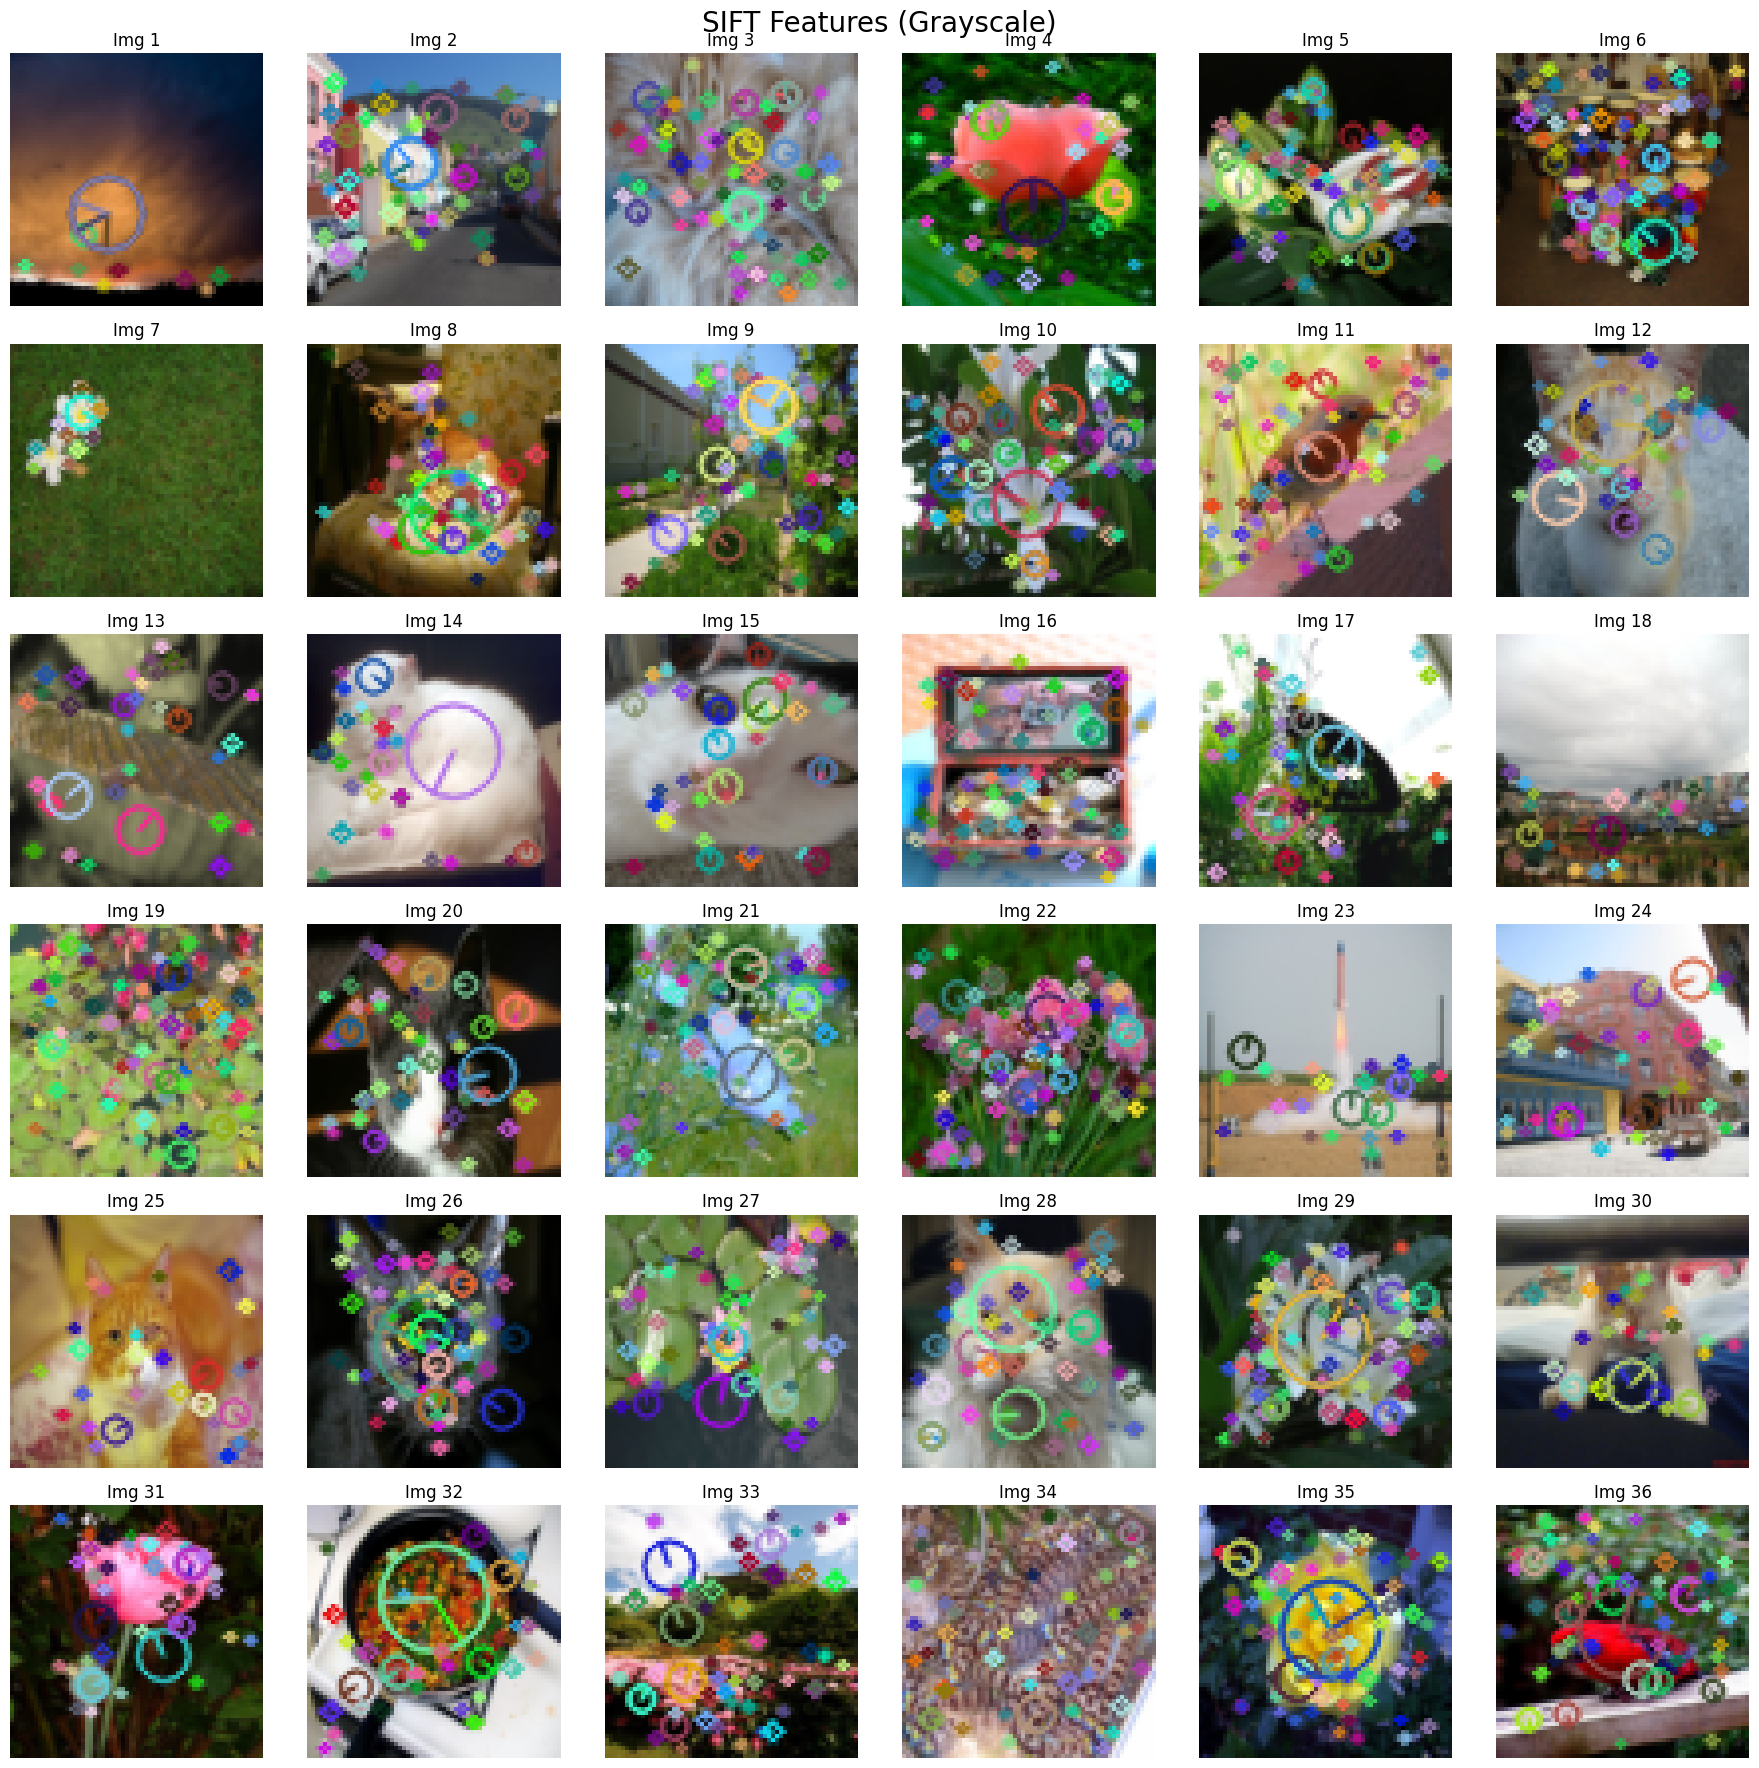

In [ ]:
import cv2
import matplotlib.pyplot as plt

sift = cv2.SIFT_create()
num_samples = 36

plt.figure(figsize=(18, 18))

for i in range(num_samples):
    img = o_x[i]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    keypoints, _ = sift.detectAndCompute(gray, None)
    img_kp = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.subplot(6, 6, i + 1)
    plt.imshow(img_kp)
    plt.title(f"Img {i+1}")
    plt.axis("off")

plt.suptitle("SIFT Features", fontsize=20)
plt.tight_layout()
plt.show()

## 5. Convert labels to match shape

In [36]:
train_y = Y.squeeze()
test_y = test_y.squeeze()

## 5. ANN model

In [37]:
import torch.nn as nn
import torch.optim as optim

class ANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

model = ANN(nx)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

## 5. Train loop

In [38]:
epochs = 1000
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    # Forward pass
    outputs = model(train_x).squeeze()
    loss = criterion(outputs, train_y)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        preds = (outputs > 0.5).float()
        acc = (preds == train_y).float().mean().item()
        train_losses.append(loss.item())
        train_accuracies.append(acc)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Train Acc: {acc*100:.2f}%")

print("\\nTraining Finished!")

Epoch 100/1000, Loss: 0.2854, Train Acc: 86.60%
Epoch 200/1000, Loss: 0.0931, Train Acc: 96.65%
Epoch 300/1000, Loss: 0.0470, Train Acc: 97.61%
Epoch 400/1000, Loss: 0.1184, Train Acc: 95.69%
Epoch 500/1000, Loss: 0.1664, Train Acc: 93.30%
Epoch 600/1000, Loss: 0.1166, Train Acc: 94.74%
Epoch 700/1000, Loss: 0.3213, Train Acc: 82.30%
Epoch 800/1000, Loss: 0.2343, Train Acc: 85.17%
Epoch 900/1000, Loss: 0.2106, Train Acc: 83.73%
Epoch 1000/1000, Loss: 0.1863, Train Acc: 89.00%
\nTraining Finished!


## 5. Test evaluation

In [39]:
final_train_acc = (model(train_x).squeeze().gt(0.5).float() == train_y).float().mean().item()

model.eval() 
with torch.no_grad():
    test_x_flat = test_x.reshape(test_x.shape[0], -1) / 255.0
    test_outputs = model(test_x_flat).squeeze()
    test_preds = (test_outputs > 0.5).float()
    test_acc = (test_preds == test_y).float().mean().item()
    
    print(f"\\nFinal Training Accuracy: {final_train_acc*100:.2f}%")
    print(f"Final Test Accuracy: {test_acc*100:.2f}%")

\nFinal Training Accuracy: 87.08%
Final Test Accuracy: 78.00%
